# Modelo Beta-Binomial Jerárquico — Surtimiento de Recetas ISSSTE 2018-2024

Notebook reproducible: carga datos desde los CSVs pregenerados en `data/` (no requiere DuckDB ni los parquets originales).  
El análisis completo se puede reproducir con `agg_linea_2018_2024.csv` y `agg_folio_2018_2024.csv`.

**Unidades de análisis:**
- `linea`: cada renglón de medicamento es un experimento Bernoulli (θ = P de que esa línea sea surtida completa)
- `folio`: cada receta es un experimento Bernoulli (θ = P de que el paciente salga con **toda** su medicación)

In [1]:
import pathlib, sys
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('mode.chained_assignment', None)
pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 200)

%load_ext autoreload
%autoreload 2

# Raíz del proyecto
_cwd = pathlib.Path().resolve()
ROOT = next((p for p in [_cwd, *_cwd.parents] if (p / 'src').exists()), _cwd)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_DIR = ROOT / 'data'
print(f'ROOT     : {ROOT}')
print(f'DATA_DIR : {DATA_DIR}')

ROOT     : C:\Users\Oscar David\Documents\Maestría_local\Tercer_trimestre\Introduction_to_probabilistic_programming\final-project-pp-dj
DATA_DIR : C:\Users\Oscar David\Documents\Maestría_local\Tercer_trimestre\Introduction_to_probabilistic_programming\final-project-pp-dj\data


## 1. Carga de datos

Los CSVs son el resultado de agregar ~400 millones de líneas de los parquets SIAM-ISSSTE con DuckDB.  
Cada fila representa una combinación única `(estado, anio, mes_num)` con el conteo de recetas/líneas surtidas y totales.

In [2]:
agg_linea = pd.read_csv(DATA_DIR / 'agg_linea_2018_2024.csv')
agg_folio = pd.read_csv(DATA_DIR / 'agg_folio_2018_2024.csv')

print('=== agg_linea ===')
print(f'Filas: {len(agg_linea):,}  |  Columnas: {agg_linea.columns.tolist()}')
print(agg_linea.head(5).to_string(index=False))
print()
print('=== agg_folio ===')
print(f'Filas: {len(agg_folio):,}  |  Columnas: {agg_folio.columns.tolist()}')
print(agg_folio.head(5).to_string(index=False))

=== agg_linea ===
Filas: 2,688  |  Columnas: ['estado', 'anio', 'mes_num', 'surtidas', 'total']
        estado  anio  mes_num  surtidas  total
AGUASCALIENTES  2018        1     75297  75624
AGUASCALIENTES  2018        2     68680  69094
AGUASCALIENTES  2018        3     69804  70149
AGUASCALIENTES  2018        4     71307  71656
AGUASCALIENTES  2018        5     76571  76999

=== agg_folio ===
Filas: 2,688  |  Columnas: ['estado', 'anio', 'mes_num', 'surtidas', 'total']
        estado  anio  mes_num  surtidas  total
AGUASCALIENTES  2018        1   44166.0  44485
AGUASCALIENTES  2018        2   40386.0  40791
AGUASCALIENTES  2018        3   40932.0  41270
AGUASCALIENTES  2018        4   42160.0  42495
AGUASCALIENTES  2018        5   44995.0  45418


In [3]:
# Cobertura temporal y geográfica
for nombre, df in [('linea', agg_linea), ('folio', agg_folio)]:
    resumen = (
        df.groupby('anio')
        .agg(lineas=('total', 'sum'), estados=('estado', 'nunique'), meses=('mes_num', 'nunique'))
        .reset_index()
    )
    resumen['lineas'] = resumen['lineas'].map('{:,.0f}'.format)
    print(f'\n=== {nombre} ===')
    print(resumen.to_string(index=False))


=== linea ===
 anio     lineas  estados  meses
 2018 61,677,999       32     12
 2019 60,632,898       32     12
 2020 44,720,748       32     12
 2021 42,428,629       32     12
 2022 55,334,521       32     12
 2023 64,689,495       32     12
 2024 73,078,192       32     12

=== folio ===
 anio     lineas  estados  meses
 2018 37,554,284       32     12
 2019 35,707,748       32     12
 2020 27,193,146       32     12
 2021 26,231,846       32     12
 2022 33,492,386       32     12
 2023 38,330,836       32     12
 2024 40,353,303       32     12


## 2. Construcción de inputs para el modelo

`build_model_inputs` colapsa los meses a nivel `(estado, anio)` y genera los arrays de índices enteros para PyMC.

In [5]:
from bayes_data import build_model_inputs

data_linea = build_model_inputs(agg_linea)
data_folio = build_model_inputs(agg_folio)

for nombre, data in [('linea', data_linea), ('folio', data_folio)]:
    print(f'\n=== {nombre} ===')
    print(f"  Estados : {len(data['coords']['estados'])}")
    print(f"  Años    : {data['coords']['anios']}")
    print(f"  N filas : {len(data['n_obs'])}")
    print(f"  n_obs   : {data['n_obs'].min():,} – {data['n_obs'].max():,}")
    print(f"  theta   : {data['theta_obs'].min():.4f} – {data['theta_obs'].max():.4f}")


=== linea ===
  Estados : 32
  Años    : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  N filas : 224
  n_obs   : 313,822 – 14,000,980
  theta   : 0.8942 – 0.9971

=== folio ===
  Estados : 32
  Años    : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  N filas : 224
  n_obs   : 206,466 – 7,718,753
  theta   : 0.8602 – 0.9958


In [6]:
print('Primeras filas — nivel (estado, anio):')
data_folio['df_model'].head(14)

Primeras filas — nivel (estado, anio):


,estado,anio,surtidas,total
0,AGUASCALIENTES,2018,499160.0,503813
1,AGUASCALIENTES,2019,470536.0,477426
2,AGUASCALIENTES,2020,351012.0,372130
3,AGUASCALIENTES,2021,350040.0,359803
4,AGUASCALIENTES,2022,457139.0,466302
5,AGUASCALIENTES,2023,506976.0,515213
6,AGUASCALIENTES,2024,489385.0,504324
7,BAJA CALIFORNIA,2018,667804.0,681223
8,BAJA CALIFORNIA,2019,609113.0,629036
9,BAJA CALIFORNIA,2020,495058.0,537997


## 3. Caso de prueba: Colima 2020

Usamos folio como unidad de análisis — el supuesto de independencia es más defendible porque los folios corresponden a pacientes distintos.

In [7]:
df_f = data_folio['df_model']

_ESTADO_PRUEBA = 'COLIMA'
_ANIO_PRUEBA   = 2020

_row  = df_f[(df_f['estado'] == _ESTADO_PRUEBA) & (df_f['anio'] == _ANIO_PRUEBA)].iloc[0]
N_OBS = int(_row['total'])
K_OBS = int(_row['surtidas'])

print(f'Estado               : {_ESTADO_PRUEBA}')
print(f'Año                  : {_ANIO_PRUEBA}')
print(f'n (folios totales)   : {N_OBS:>10,}')
print(f'k (folios completos) : {K_OBS:>10,}')
print(f'θ observado          : {K_OBS/N_OBS:.4f}  ({100*(1-K_OBS/N_OBS):.2f}% desabasto)')

Estado               : COLIMA
Año                  : 2020
n (folios totales)   :    213,557
k (folios completos) :    207,626
θ observado          : 0.9722  (2.78% desabasto)


## 4. Solución analítica Beta-Binomial

El modelo Beta-Binomial con prior conjugado tiene solución cerrada:

$$\theta \sim \text{Beta}(\alpha, \beta) \qquad k \sim \text{Binomial}(n, \theta)$$

$$\theta \mid k, n \sim \text{Beta}(\alpha + k,\; \beta + n - k)$$

Usamos un prior no informativo `Beta(1, 1)` (uniforme). Con \(n\) tan grande, el posterior está completamente dominado por los datos.

Prior    : Beta(1, 1)  →  media = 0.50
Posterior: Beta(207,627, 5,932)
  media      : 0.972223
  std        : 0.000356
  HDI 94%%   : [0.971551, 0.972888]
  θ observado: 0.972228


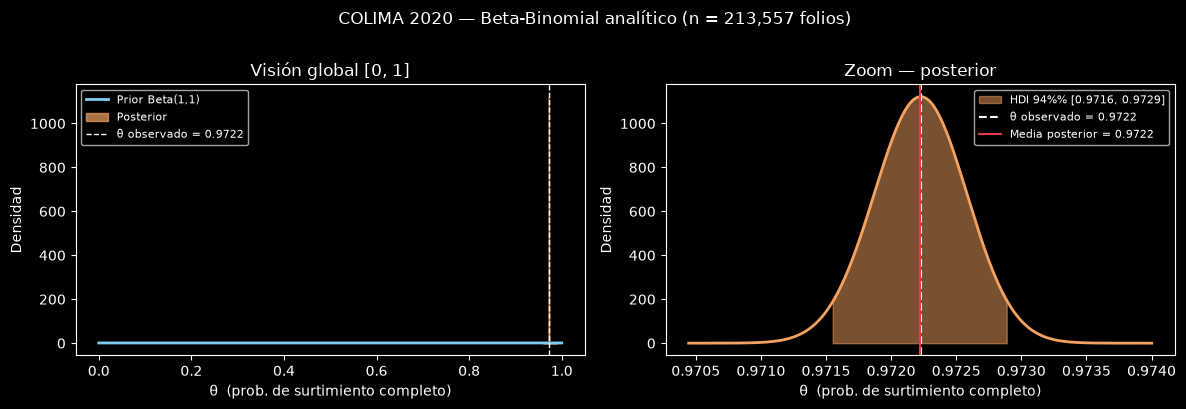

In [8]:
ALPHA_PRIOR = 1
BETA_PRIOR  = 1

alpha_post = ALPHA_PRIOR + K_OBS
beta_post  = BETA_PRIOR  + (N_OBS - K_OBS)

prior_dist = st.beta(ALPHA_PRIOR, BETA_PRIOR)
post_dist  = st.beta(alpha_post, beta_post)

theta_obs  = K_OBS / N_OBS
media_post = post_dist.mean()
hdi_low, hdi_high = post_dist.interval(0.94)

print(f'Prior    : Beta({ALPHA_PRIOR}, {BETA_PRIOR})  →  media = {prior_dist.mean():.2f}')
print(f'Posterior: Beta({alpha_post:,}, {beta_post:,})')
print(f'  media      : {media_post:.6f}')
print(f'  std        : {post_dist.std():.6f}')
print(f'  HDI 94%%   : [{hdi_low:.6f}, {hdi_high:.6f}]')
print(f'  θ observado: {theta_obs:.6f}')

plt.style.use('dark_background')
fig, (ax_global, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{_ESTADO_PRUEBA} {_ANIO_PRUEBA} — Beta-Binomial analítico (n = {N_OBS:,} folios)',
             fontsize=12, y=1.01)

x_full = np.linspace(0, 1, 2000)
ax_global.plot(x_full, prior_dist.pdf(x_full), color='#7ecef4', lw=2, label='Prior Beta(1,1)')
x_spike = np.linspace(0.96, 0.99, 2000)
ax_global.fill_between(x_spike, post_dist.pdf(x_spike), alpha=0.7, color='#f4a261', label='Posterior')
ax_global.axvline(theta_obs, color='white', ls='--', lw=1, label=f'θ observado = {theta_obs:.4f}')
ax_global.set_xlabel('θ  (prob. de surtimiento completo)')
ax_global.set_ylabel('Densidad')
ax_global.set_title('Visión global [0, 1]')
ax_global.legend(fontsize=8)

sigma  = post_dist.std()
x_zoom = np.linspace(media_post - 5*sigma, media_post + 5*sigma, 2000)
ax_zoom.plot(x_zoom, post_dist.pdf(x_zoom), color='#f4a261', lw=2)
ax_zoom.fill_between(
    x_zoom, post_dist.pdf(x_zoom),
    where=(x_zoom >= hdi_low) & (x_zoom <= hdi_high),
    alpha=0.5, color='#f4a261', label=f'HDI 94%% [{hdi_low:.4f}, {hdi_high:.4f}]'
)
ax_zoom.axvline(theta_obs, color='white',   ls='--', lw=1.5, label=f'θ observado = {theta_obs:.4f}')
ax_zoom.axvline(media_post, color='#e63946', ls='-',  lw=1.5, label=f'Media posterior = {media_post:.4f}')
ax_zoom.set_xlabel('θ  (prob. de surtimiento completo)')
ax_zoom.set_ylabel('Densidad')
ax_zoom.set_title('Zoom — posterior')
ax_zoom.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
ax_zoom.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Modelo PyMC — MCMC

Verificamos que PyMC replica la solución analítica. Con \(n\) grande y prior conjugado, ambos deben coincidir.

In [9]:
import pymc
import pytensor as pt
import arviz as az

pt.config.cxx = '/usr/bin/clang++'  # Mac: compilador C++ para PyTensor
%config InlineBackend.figure_format = 'retina'

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\Oscar David\Documents\Maestría_local\Tercer_trimestre\Introduction_to_probabilistic_programming\final-project-pp-dj\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [10]:
with pymc.Model() as modelo_beta_binomial:
    theta = pymc.Beta('theta', alpha=1, beta=1)
    y     = pymc.Binomial('y', n=N_OBS, p=theta, observed=K_OBS)

    prior_samples = pymc.sample_prior_predictive(draws=5000, random_seed=42,
                                                  return_inferencedata=True)

Sampling: [theta, y]


In [11]:
with modelo_beta_binomial:
    trace = pymc.sample(chains=5, draws=5000, tune=1000,
                        target_accept=0.95, random_seed=42,
                        return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 4 jobs)
NUTS: [theta]


Output()

Sampling 5 chains for 1_000 tune and 5_000 draw iterations (5_000 + 25_000 draws total) took 27 seconds.


In [12]:
with modelo_beta_binomial:
    ppc = pymc.sample_posterior_predictive(trace, random_seed=42)

Sampling: [y]


Output()

## 6. Diagnósticos de convergencia

In [13]:
print(az.summary(trace, var_names=['theta']).to_string())

        mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
theta  0.972  0.0   0.972    0.973        0.0      0.0    9798.0   10281.0    1.0


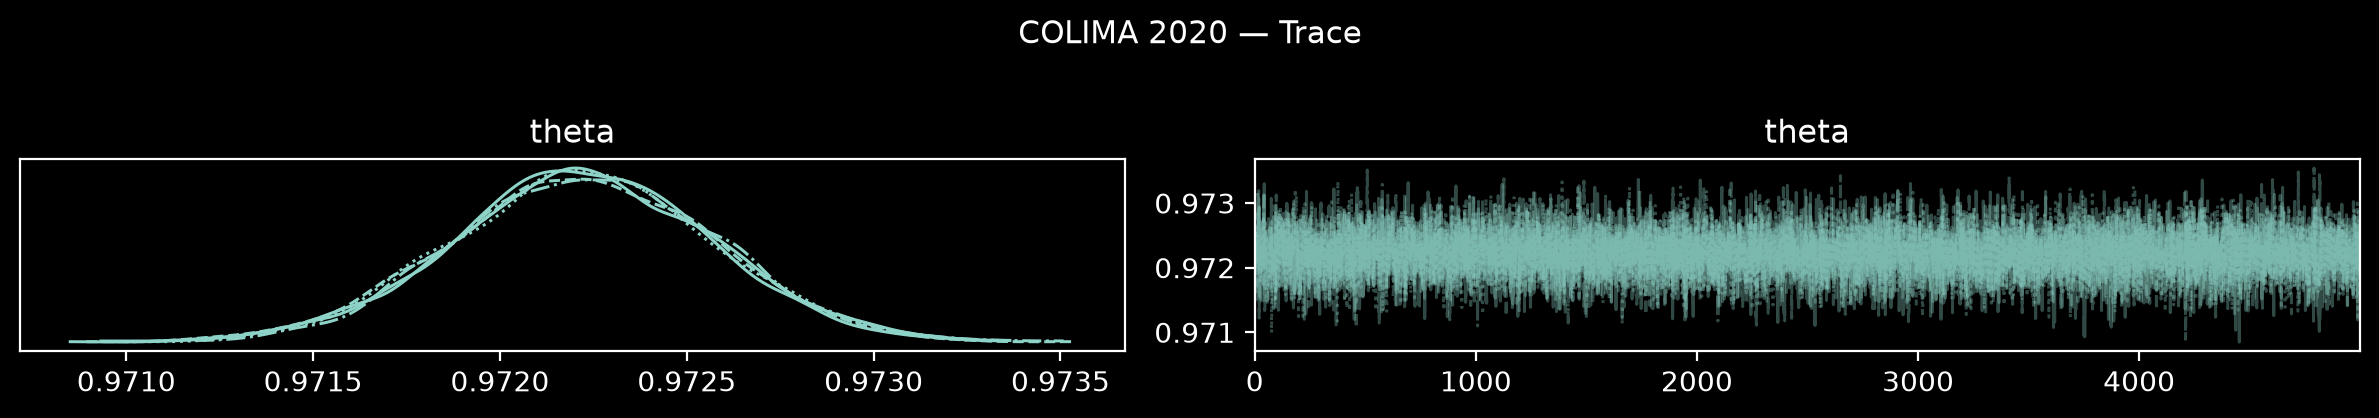

In [14]:
az.plot_trace(trace, var_names=['theta'])
plt.suptitle(f'{_ESTADO_PRUEBA} {_ANIO_PRUEBA} — Trace', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

ESS:
<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    theta    float64 8B 9.798e+03
Attributes:
    created_at:                 2026-06-23T00:39:05.594114+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              27.217236280441284
    tuning_steps:               1000


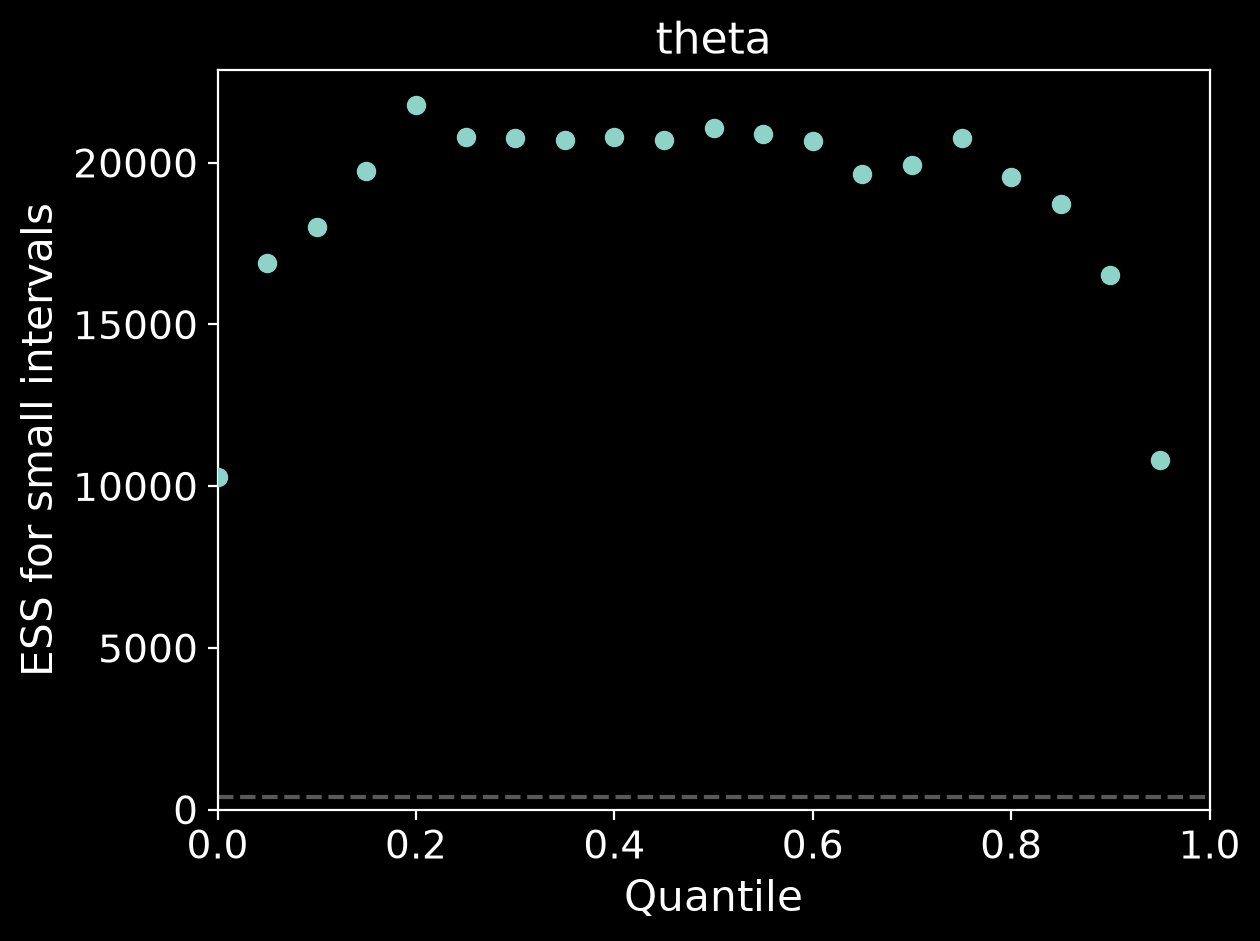

In [15]:
print('ESS:')
print(az.ess(trace))
az.plot_ess(trace)
plt.show()

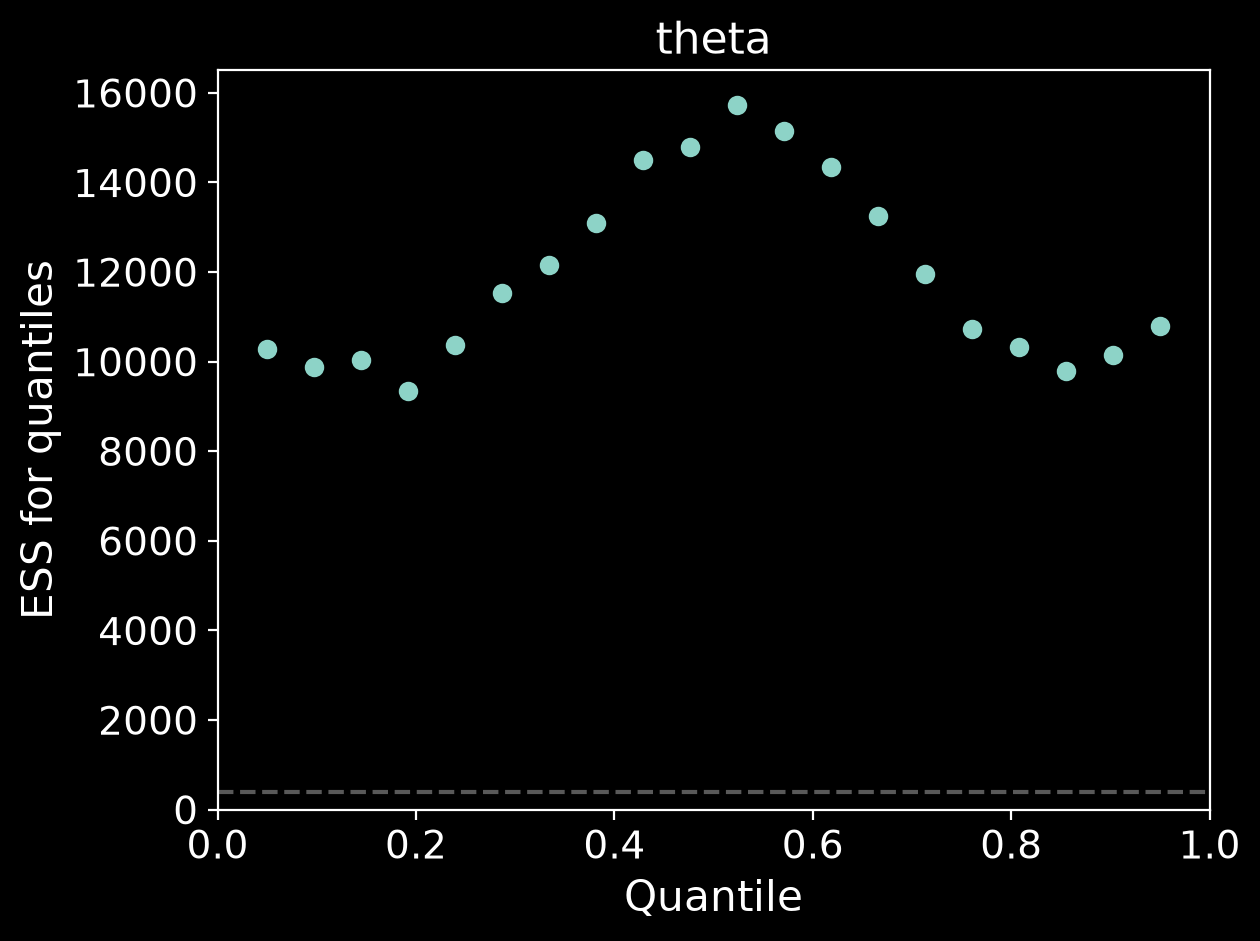

In [16]:
az.plot_ess(trace, kind='quantile')
plt.show()

In [17]:
print('R-hat:')
print(az.rhat(trace))

R-hat:
<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    theta    float64 8B 1.001
Attributes:
    created_at:                 2026-06-23T00:39:05.594114+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              27.217236280441284
    tuning_steps:               1000


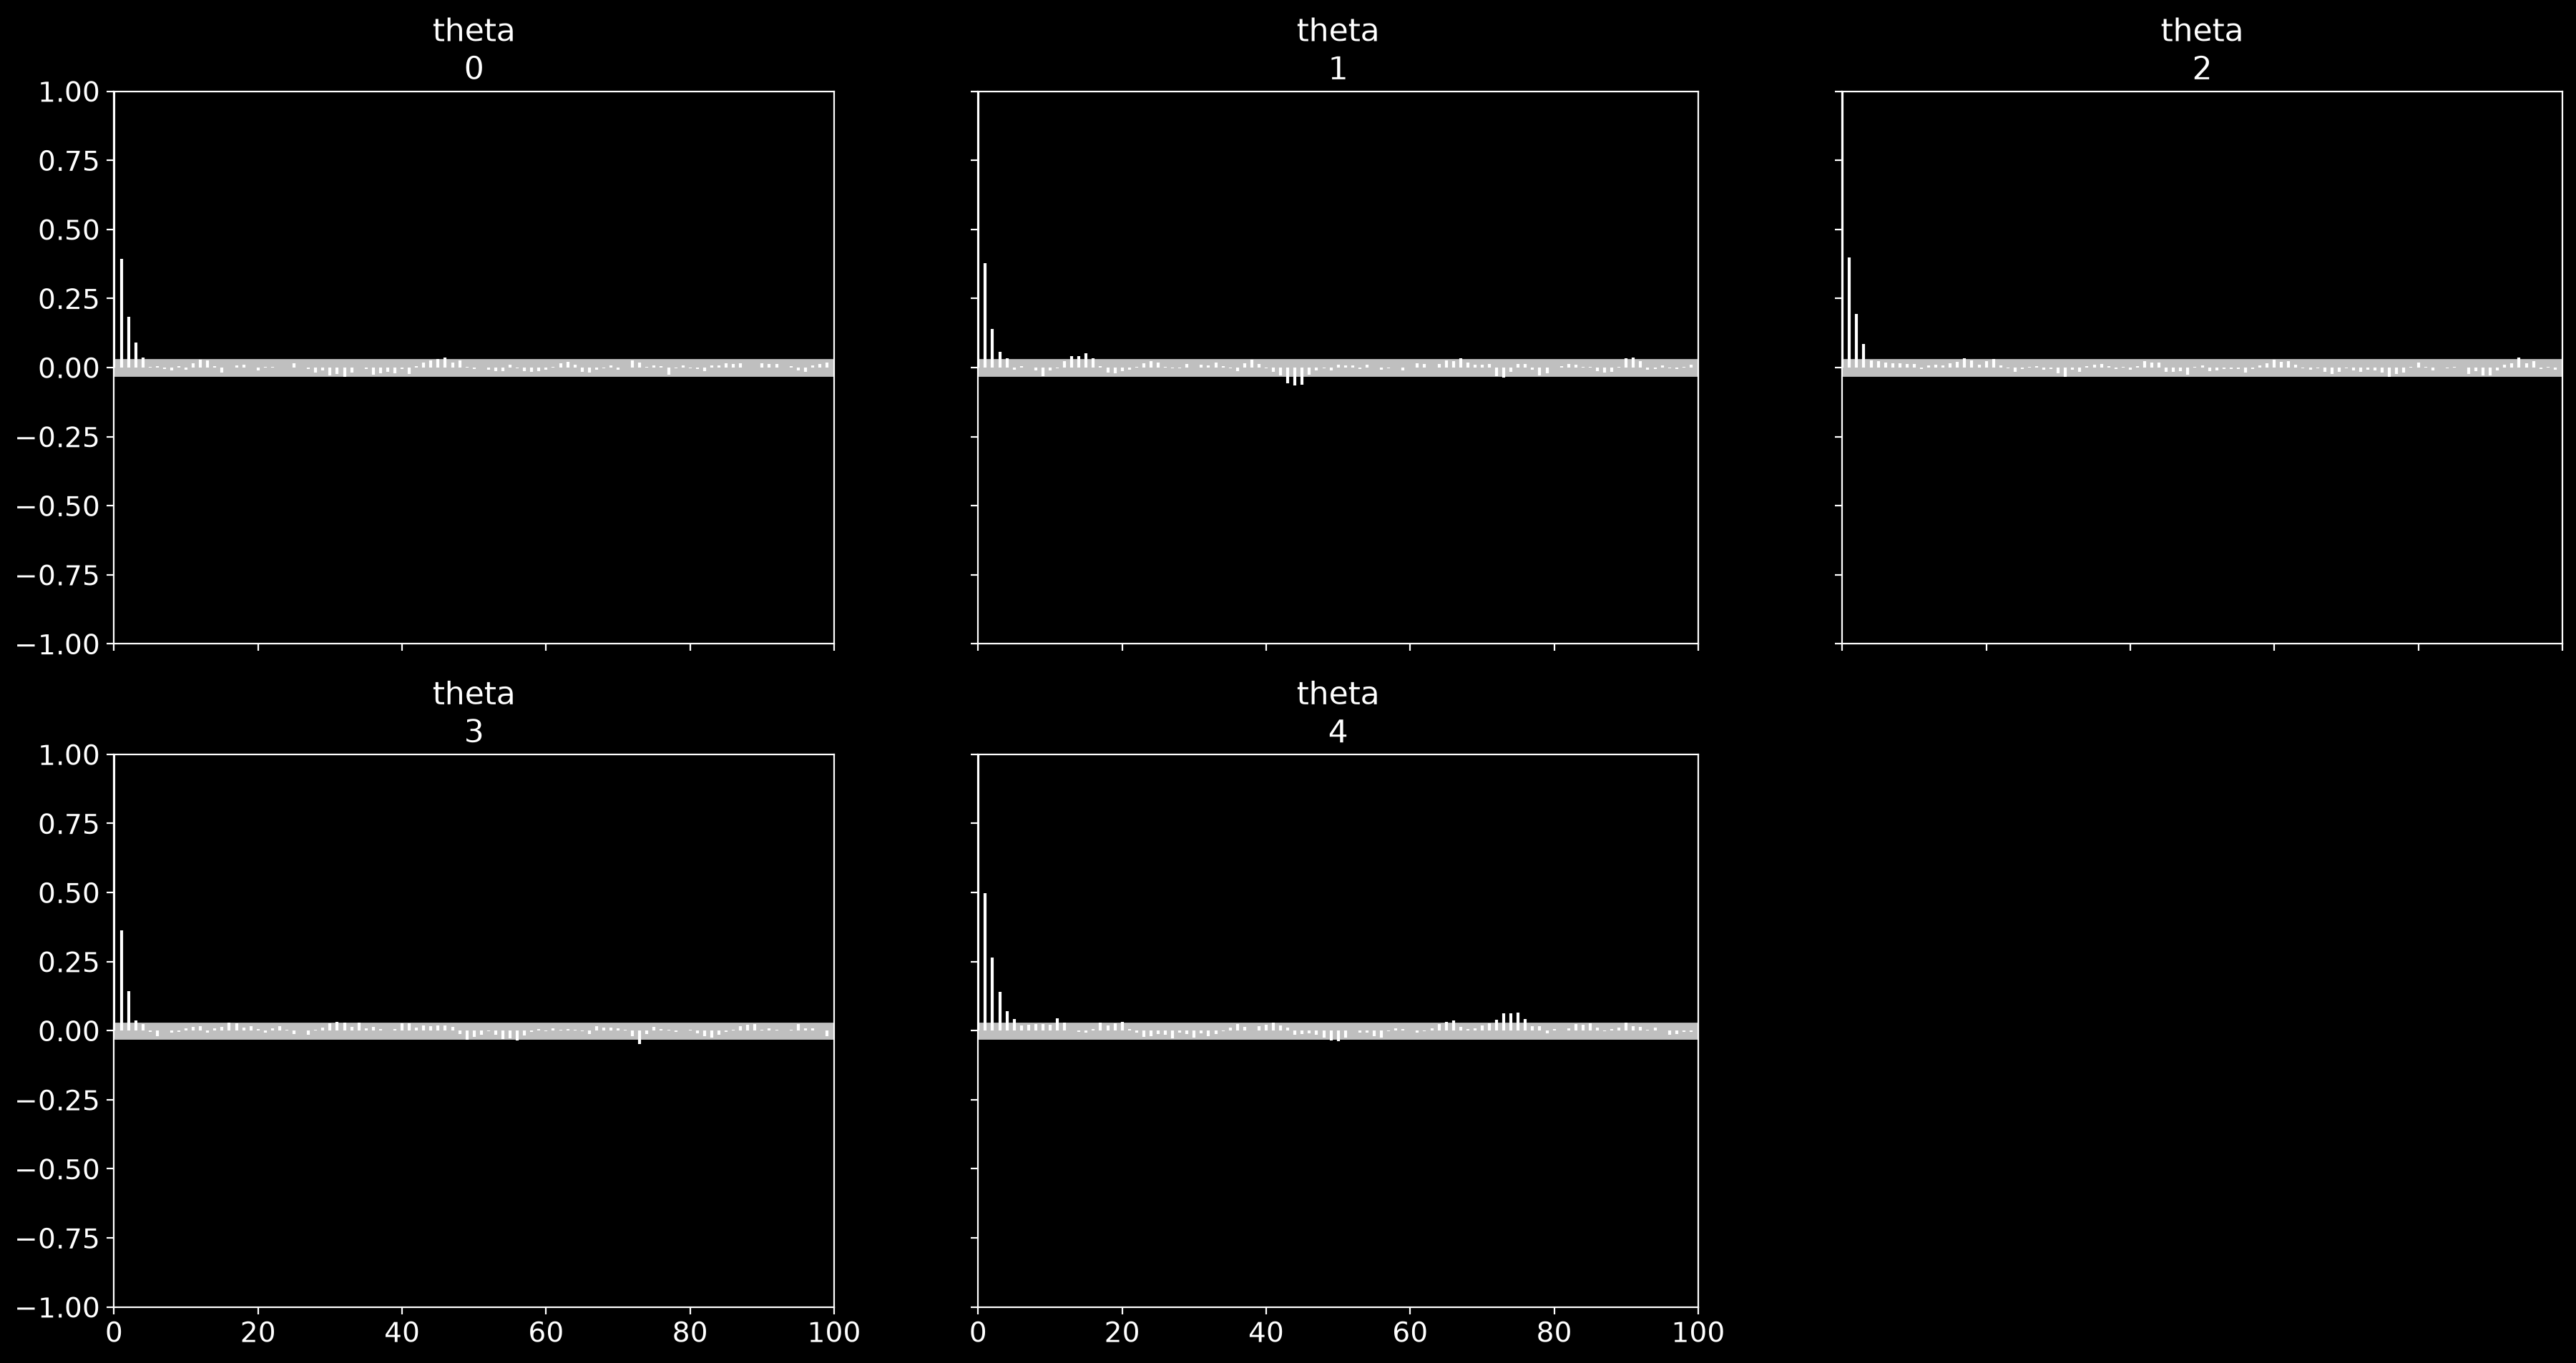

In [18]:
az.plot_autocorr(trace)
plt.show()

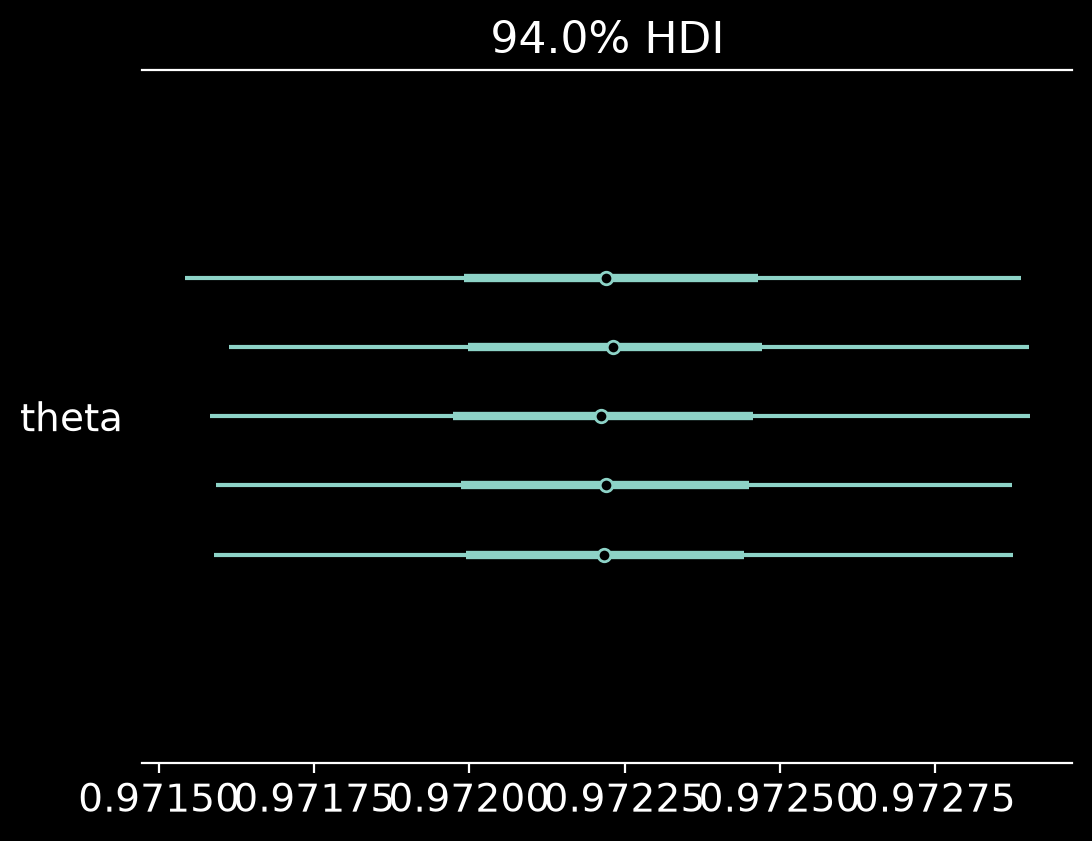

In [19]:
az.plot_forest(trace, var_names=['theta'])
plt.show()

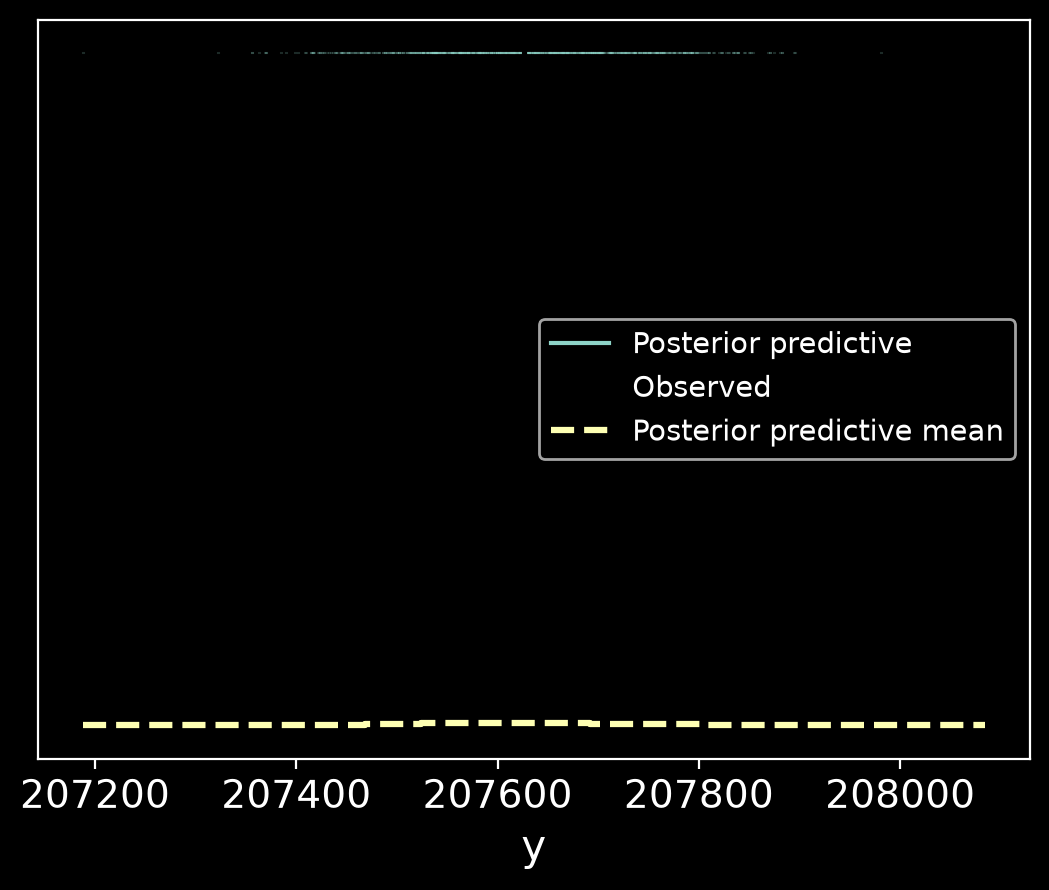

In [20]:
az.plot_ppc(ppc, num_pp_samples=1000)
plt.show()

## 7. Analítico vs PyMC + Posterior Predictive Check

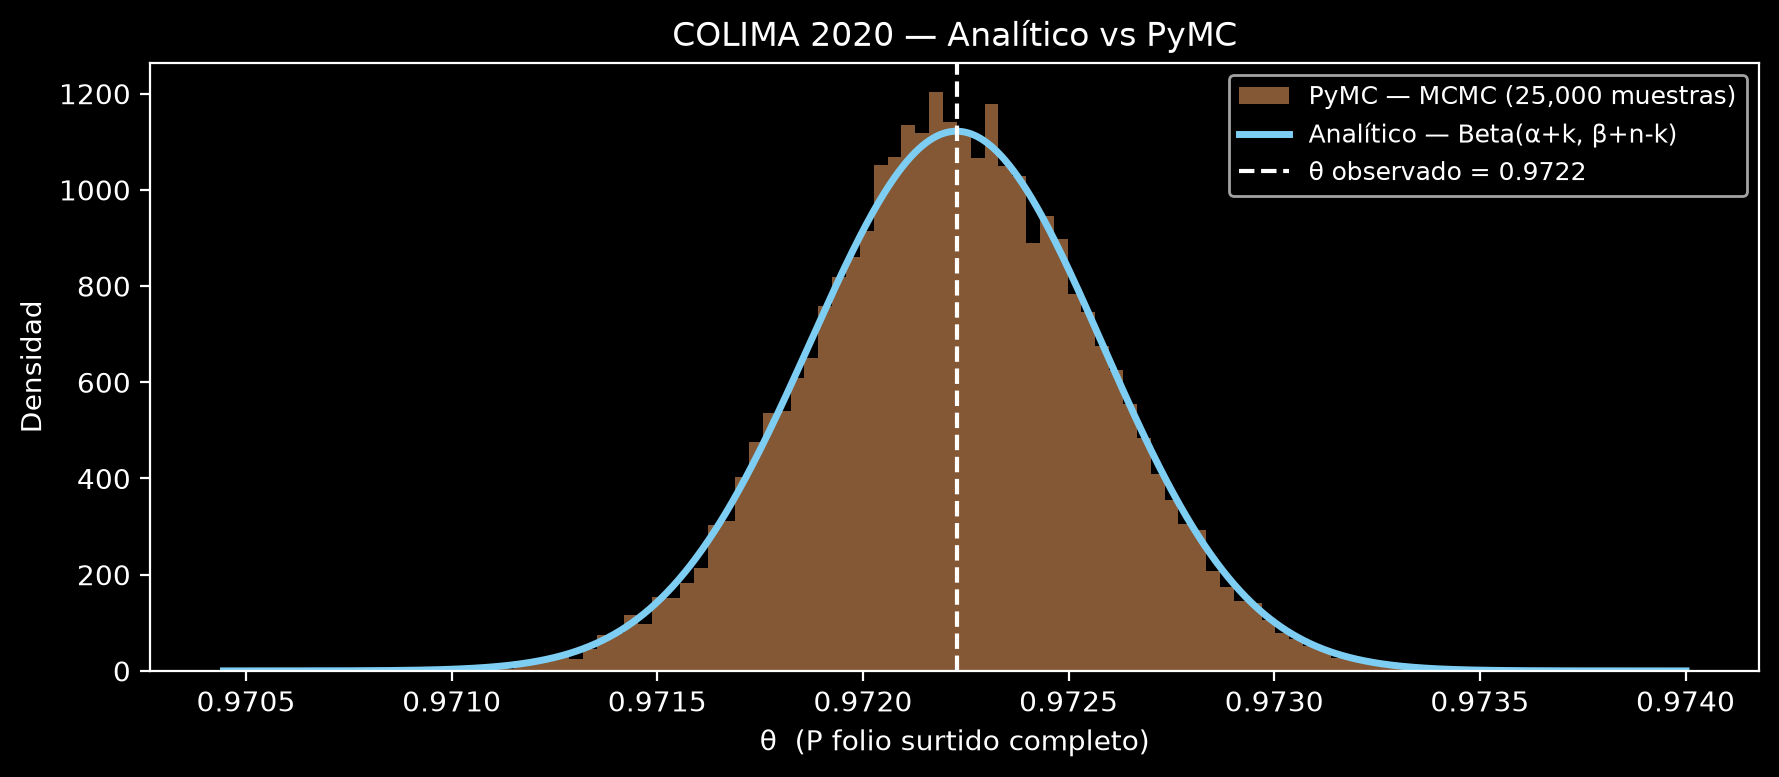

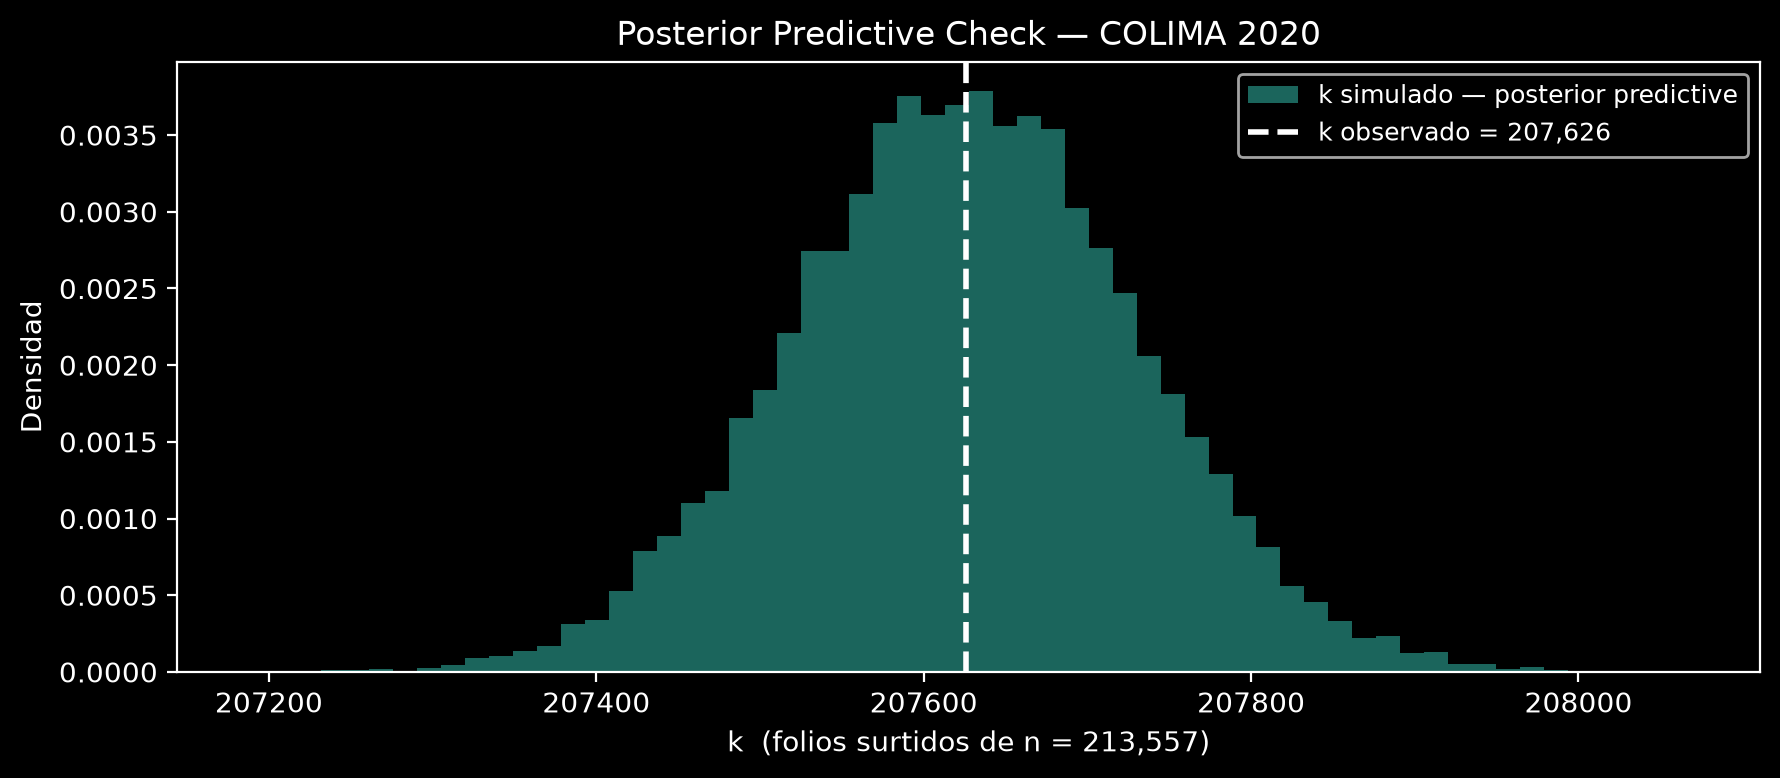

In [21]:
theta_samples = trace.posterior['theta'].values.flatten()

sigma  = post_dist.std()
x_zoom = np.linspace(media_post - 5*sigma, media_post + 5*sigma, 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(theta_samples, bins=80, density=True, alpha=0.55,
        color='#f4a261', label=f'PyMC — MCMC ({len(theta_samples):,} muestras)')
ax.plot(x_zoom, post_dist.pdf(x_zoom), color='#7ecef4', lw=2.5,
        label='Analítico — Beta(α+k, β+n-k)')
ax.axvline(theta_obs, color='white', ls='--', lw=1.5,
           label=f'θ observado = {theta_obs:.4f}')
ax.set_xlabel('θ  (P folio surtido completo)')
ax.set_ylabel('Densidad')
ax.set_title(f'{_ESTADO_PRUEBA} {_ANIO_PRUEBA} — Analítico vs PyMC')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

y_ppc = ppc.posterior_predictive['y'].values.flatten()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_ppc, bins=60, density=True, alpha=0.65,
        color='#2a9d8f', label='k simulado — posterior predictive')
ax.axvline(K_OBS, color='white', ls='--', lw=2,
           label=f'k observado = {K_OBS:,}')
ax.set_xlabel(f'k  (folios surtidos de n = {N_OBS:,})')
ax.set_ylabel('Densidad')
ax.set_title(f'Posterior Predictive Check — {_ESTADO_PRUEBA} {_ANIO_PRUEBA}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()